In [1]:
import numpy               as np
import seaborn             as sns
import pandas              as pd
import libraries.plotting  as slp
import libraries.utilities as sul
import os

sns.set_theme()

We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
slab_folder = 'input/slabs/BiSeI-slab'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = np.loadtxt(f'{bulk_folder}/single_shot_energy')

# Load bulk information
slab_data = sul.load_json(filename=f'{bulk_folder}/slab_data.json')

bulk_energy_per_atom = bulk_energy / slab_data['number_of_sites']

In [4]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, miller_index_str in enumerate(os.listdir(slab_folder)):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'

    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load slab information
    slab_data = sul.load_json(filename=f'{miller_folder}/slab_data.json')

    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab_data['miller_index']}')
    print(f'Shift: {slab_data['shift']:.2g}')
    print(f'Surface area: {slab_data['surface_area']:.2g}')
    print(f'Number of sites: {slab_data['number_of_sites']}')

    # Load the single-shot energy
    ssc_energy = np.loadtxt(f'{miller_folder}/single_shot_energy')

    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / slab_data['number_of_sites']
    
    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(ssc_energy_per_atom, bulk_energy_per_atom, slab_data['surface_area'])

    # Load the slab energy
    np.savetxt(f'{miller_folder}/surface_energy_of_formation', [surface_energy_of_formation])

    print(f'\t$E_{surface}$ = {surface_energy_of_formation} eV/atom/Å^2')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])


Miller index: [0, 1, 1]
Shift: 0.0619558690330137
Surface area: 56.22124855323555
Number of sites: 48
	0.0009626120264610432 eV/atom/Å^2

Miller index: [2, 1, 1]
Shift: 0.11454615458436557
Surface area: 185.5352020583554
Number of sites: 144
	0.00016197480286423338 eV/atom/Å^2

Miller index: [2, 0, 1]
Shift: 5.329070518200751e-15
Surface area: 180.4051328076364
Number of sites: 120
	0.0001937936823409511 eV/atom/Å^2

Miller index: [0, 0, 1]
Shift: 0.5000000000000107
Surface area: 35.826380355693765
Number of sites: 24
	0.0016599191780724278 eV/atom/Å^2

Miller index: [1, 1, 1]
Shift: 0.05427885790007281
Surface area: 104.7685515427803
Number of sites: 72
	0.00036355547532794367 eV/atom/Å^2

Miller index: [0, 1, 0]
Shift: 0.1536304826124137
Surface area: 43.32781161671855
Number of sites: 36
	0.0013632124883523524 eV/atom/Å^2

Miller index: [1, 0, 1]
Shift: 0.4999999999999609
Surface area: 95.3894655236015
Number of sites: 72
	0.00031799036077050097 eV/atom/Å^2

Miller index: [2, 1, 0]

# Extract local minimas and generate input files

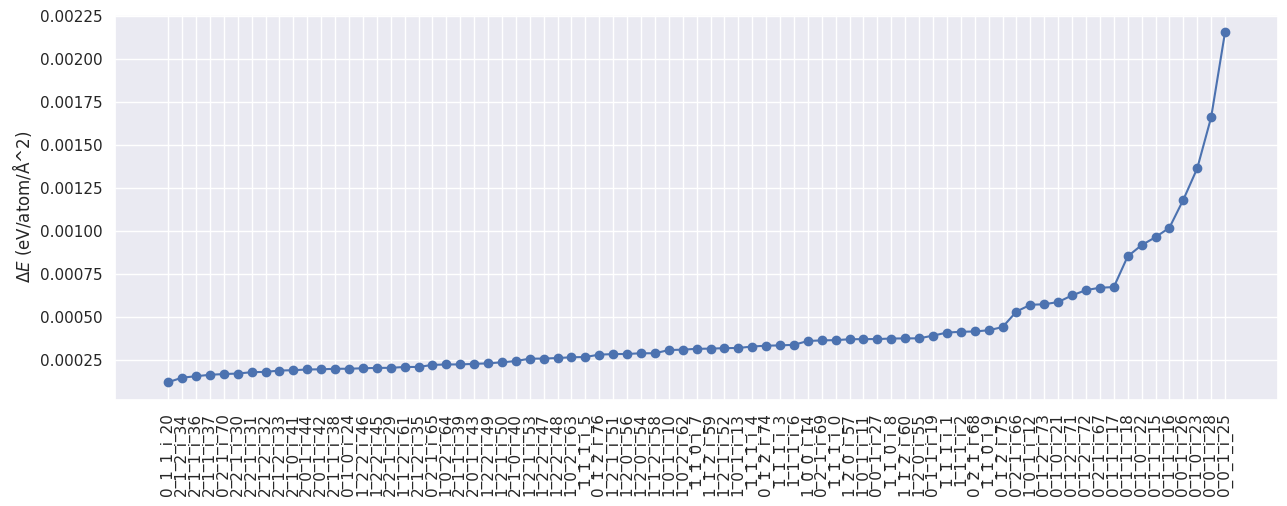

In [6]:
slp.plot_ranking(surface_energies_of_formation,
                filename=f'{slab_folder}/ranking.eps')